In [53]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [34]:
# Load data
data = pd.read_csv(r"..\Datasets\For analysis\full_data_CIFAR100_v3.csv")

# Remove experiments that have another split
data = data[data["rate"]==8]

# Rename so it looks better for plots
rename_map = {
    "vit_l_32": "ViT-L/32",
    "vit_b_16": "ViT-B/16",
    "vit_b_32": "ViT-B/32",
    "vit_small_patch16_224": "ViT-S/16",
    "vit_small_patch32_224": "ViT-S/32",
    "vit_tiny_patch16_224": "ViT-T/16",
}

data["model"] = data["model"].replace(rename_map)


# Plot energy metrics against each other

C:\Users\Shelg\AppData\Local\Temp\ipykernel_1596\1812777185.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab10", len(models))


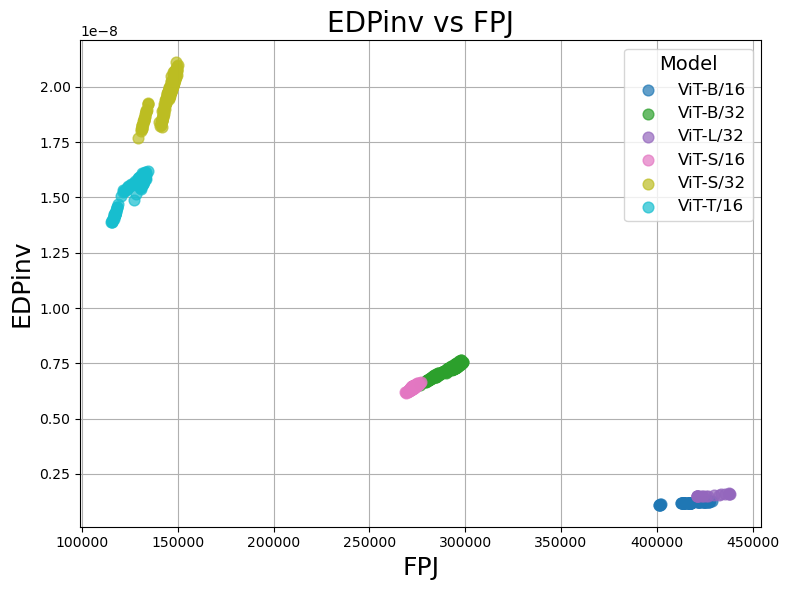

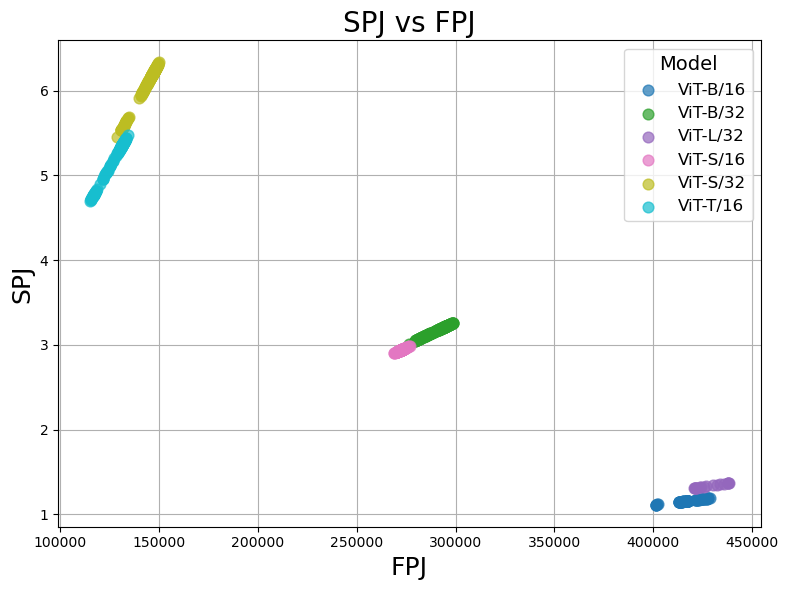

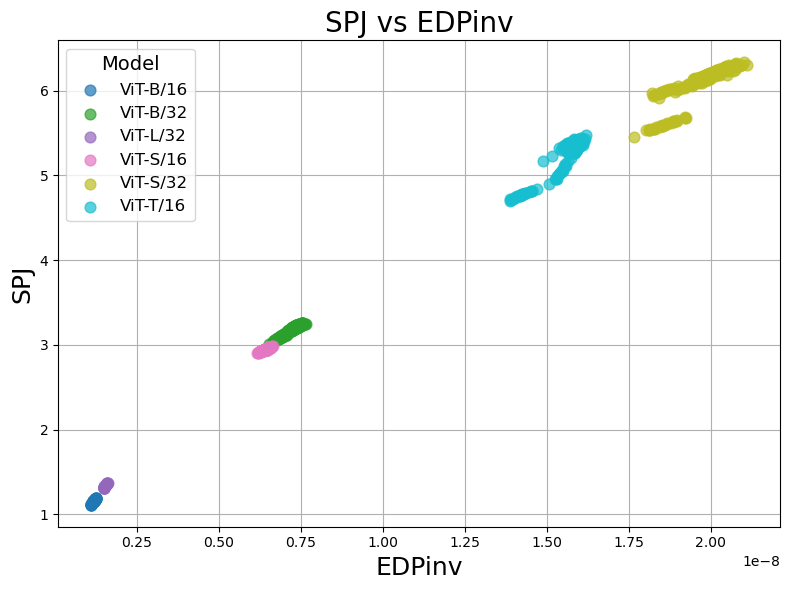

In [38]:
# The code for plotting energy_metrics is partly written with help of chatGPT

def energy_metrics(df, save=False):
    # Plot correlation between energy efficiency metrics
    metrics = ["FPJ", "EDPinv", "SPJ"]
    pairs   = list(combinations(metrics, 2))

    # unique models and colormap
    models = sorted(df["model"].unique())
    cmap   = plt.cm.get_cmap("tab10", len(models))

    for x_metric, y_metric in pairs:
        fig, ax = plt.subplots(figsize=(8, 6))

        for i, m in enumerate(models):
            subset = df[df["model"] == m]

            ax.scatter(
                subset[x_metric],
                subset[y_metric],
                s=60,
                alpha=0.7,
                label=m,
                color=cmap(i),
                zorder=5,
            )

        ax.set_xlabel(x_metric, fontsize=18)
        ax.set_ylabel(y_metric, fontsize=18)
        ax.set_title(f"{y_metric} vs {x_metric}", fontsize=20)
        ax.grid(True)
        ax.legend(title="Model", title_fontsize=14, fontsize=12)

        plt.tight_layout()
        if save:
            path = r"..\Plots\QR1_v2\energy_metrics"
            folder = Path(path)
            save_as = folder / f"{x_metric}_vs_{y_metric}.png"
            plt.savefig(save_as,
                        dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

# call
energy_metrics(data, save=True)


# Performance vs energy efficiency

In [ ]:
# The code for plotting energy_performance is partly written with help of chatGPT


def energy_performance(df, save: bool):
    energy_metrics = ["SPJ", "EDPinv", "FPJ"]
    performance_metrics = ["accuracy", "recall", "precision", "specificity"]
    models = sorted(df["model"].unique())

    # One color per model, consistent across all figures
    cmap = plt.cm.get_cmap("tab10", len(models))
    model_to_color = {model: cmap(i) for i, model in enumerate(models)}

    for e in energy_metrics:
        for p in performance_metrics:
            fig, ax = plt.subplots(figsize=(8, 6))

            # Group by model and plot each subset
            for model, group in df.groupby("model"):
                ax.scatter(
                    group[e],
                    group[p],
                    s=60,
                    label=model,
                    color=model_to_color[model],
                    zorder=5,
                )

            ax.set_xlabel(e, fontsize=18)
            ax.set_ylabel(p.capitalize(), fontsize=18)
            ax.grid(True)
            ax.legend(title="Model", title_fontsize=14, fontsize=12)
            ax.set_title(f"{e} vs {p}", fontsize=20)

            plt.tight_layout()

            if save:
                path = r"..\Plots\QR1_v2\energy_performance"
                folder = Path(path)
                save_as = folder / f"{e}_vs_{p}.png"
                plt.savefig(folder, dpi=300)

            plt.show()

# Usage
save = True
energy_performance(data, save)


In [ ]:
# The code for plotting Eg Pg is partly written with help of chatGPT

def Eg_PG(df, save):
    x = df["Eg"] 
    y = df["Pg"]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Get unique models
    models = df["model"].unique()

    # Create a color map
    cmap = plt.cm.get_cmap("tab10", len(models))

    for i, m in enumerate(models):
        subset = df[df["model"] == m]
        ax.scatter(
            subset["Eg"],
            subset["Pg"],
            s=60,
            alpha=0.7,
            label=m,
            color=cmap(i),
            zorder=5
        )

    ax.set_title("Pg (global metric) vs Eg (Energy Metric)", fontsize=18)
    ax.set_xlabel("Eg (Global Energy Metric): (SPJ*EDP*FPJ)", fontsize=12)
    ax.set_ylabel("Pg (Global Performance Metric", fontsize=12)
    ax.grid(True)

    ax.legend(title="Model")

    if save:
        path = r"..\Plots\QR1_v2"
        folder = Path(path)
        save_as = folder / f"Eg_vs_Pg.png"
        plt.savefig(save_as,
                    dpi=150, bbox_inches="tight")

    plt.tight_layout()
    plt.show()
    
save = False

Eg_PG(data, save)

# Stastistical analysis

Code variance inflation factor and Pearson are written with help of ChatGPT

In [58]:
# Variance inflation factor
X = data[["SPJ", "EDPinv", "FPJ"]].dropna()
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print("full dataset")
print(vif_data)


full dataset
  feature           VIF
0     SPJ     64.005043
1  EDPinv  19707.763159
2     FPJ  33280.114825


In [59]:
# Pearson correlation 
cols = X.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r, p = stats.pearsonr(X[cols[i]], X[cols[j]])
        print(f"{cols[i]} vs {cols[j]}: r = {r:.4f}, p = {p:.10f}")

SPJ vs EDPinv: r = -0.9806, p = 0.0000000000
SPJ vs FPJ: r = -0.9876, p = 0.0000000000
EDPinv vs FPJ: r = 0.9991, p = 0.0000000000
